In [1]:
import subprocess
import sys

COLAB = "google.colab" in sys.modules


def _install(package):
    if COLAB:
        ans = input(f"Install { package }? [y/n]:")
        if ans.lower() in ["y", "yes"]:
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "--quiet", package]
            )
            print(f"{ package } installed!")


def _colab_install_missing_deps(deps):
    import importlib

    for dep in deps:
        if importlib.util.find_spec(dep) is None:
            if dep == "iris":
                dep = "scitools-iris"
            _install(dep)


deps = ["pyobis", "joblib"]
_colab_install_missing_deps(deps)

# Investigating PACE and OBIS as a data source for phytoplankton observations


Created: 2026-08-25


The Plankton, Aerosol, Cloud, ocean Ecosystem (PACE) and the Ocean Biodiversity Information System (OBIS) both provide information about phytoplankton distribution on a global scale. PACE Chlorophyll is the near-surface concentration of the green pigment, chlorophyll a, at the ocean surface. Found in tiny photosynthetic organisms – phytoplankton – chlorophyll is a measure of ocean ecosystem health ([link](https://pace.oceansciences.org/recentmapdata.htm)). On the other hand, OBIS is the world’s largest global open-access infrastructure for marine biodiversity data, providing occurrence records at species levels. 

The former will have a much higher global coverage while the former will certainly be more accurate in its data. While researches can ue one to calibrate the other or mix-and-match these data to create a better final product, we wonder how easy it is to fetch them and display on a common grid.

We will use the `pyobis` and `earthaccess` libraries. Earthaccess requires a login to get download access the data. Please navigate to https://earthaccess.readthedocs.io/en/latest/user/ and follow the instructions there on how to create one.

In [2]:
import earthaccess

auth = earthaccess.login(persist=True)

We can not define our search bounding box, time span, and filter for the 1 degree dataset only, the 4 km results will also be fetched. Because it can be a lot of data, we will avoid the 4km high resolution for now with a simple filter to the results and get only the files that end with `1deg.nc` string.

The next loop downloads and save the data. We will re-download the data if we do not have it already. The local cache will save us some time and ensure we always have the data even if the server is down.

Local caching is always a good practice to preserver the data and avoid putting a lot of strain on servers with multiple identical requests.

In [3]:
from pathlib import Path

import pandas as pd
import xarray as xr

fname = "chlor_a.nc"


def fake_time(ds):
    time = ds.attrs["product_name"].split(".")[1].split("_")
    time = pd.to_datetime(time).mean()
    return ds.expand_dims(time=[time])


if not Path(fname).exists():
    results = earthaccess.search_data(
        short_name="PACE_OCI_L3M_BGC",
        temporal=("2025", "2025"),
        granule_name="*.DAY.*.0p1deg.*",
    )
    day_0p1deg = earthaccess.open(results)

    ds = xr.open_mfdataset(day_0p1deg, preprocess=fake_time)
    chlor_a = ds["chlor_a"]
    vmin, vmax = (chlor_a.attrs[i] for i in ("valid_min", "valid_max"))
    chlor_a = chlor_a.where((chlor_a >= vmin) & (chlor_a <= vmax))
    chlor_a = chlor_a.mean(dim="time").compute()
    chlor_a.to_netcdf(fname)
else:
    chlor_a = xr.open_dataarray(fname)

Now we can query OBIS for appropriate phytoplankton taxonomic groupings. Here we list some generic phytoplankton groupings which would be equivalent to the chlorophyll satellite proxy data. Luckily OBIS allows users to use the WoRMS taxonomic backbone as a way to search for more exapansize taxonomic ranks, like family.

term | WoRMS | OBIS Map
-----|-------|---------
Diatoms (Bacillariophyceae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=148899 | https://mapper.obis.org/?taxonid=148899
Dinoflagellates (Dinophyceae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=19542 | https://mapper.obis.org/?taxonid=19542
Cyanobacteria (Blue-green algae) | https://www.marinespecies.org/aphia.php?p=taxdetails&id=146537 | https://mapper.obis.org/?taxonid=146537
Coccolithophyceae | https://www.marinespecies.org/aphia.php?p=taxdetails&id=592906 | https://mapper.obis.org/?taxonid=592906

Below we do an initial test to ensure our search criterias are working with pyobis.

In [4]:
from pyobis import occurrences

# IDs from the table above.
aphia_ids = ["148899", "19542", "146537", "592906"]

query = occurrences.search(taxonid=aphia_ids, size=100)
data = query.execute()

data

2026-09-09 11:58:46 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-09-09 11:58:46 - pyobis.obisutils - INFO - 100 to be fetched. Estimated time =0.0299275445938110350 seconds
2026-09-09 11:58:46 - pyobis.obisutils - INFO - Fetching: [████████████████████████████████████████████████████████████████████████████████████████████████████] 100/100
2026-09-09 11:58:46 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-09-09 11:58:46 - pyobis.obisutils - INFO - Fetched 100 records.


,basisOfRecord,bibliographicCitation,brackish,catalogNumber,class,classid,collectionCode,coordinateUncertaintyInMeters,country,date_end,...,fieldNotes,preparations,verbatimLocality,associatedOccurrences,eventType,identificationVerificationStatus,identificationQualifier,individualCount,forma,formaid
0,MaterialSample,"Brown, M. V. et al. Continental scale monitori...",True,102.100.100/35552-EF9455B8FFF22EFC18B3DCB74655...,Coccolithophyceae,592906.0,BioPlatforms Marine microbes NRS ROT,50.0,Australia,1.498349e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,HumanObservation,Continuous Plankton Recorder (CPR) data from t...,True,23AC-43-172,Bacillariophyceae,148899.0,CPR,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,MaterialSample,"Focardi, Amaranta,Ostrowski, Martin,Goossen, K...",True,102.100.100/35991-3012DC434CD10C331A5B06F1EAFB...,Dinophyceae,19542.0,BioPlatforms Marine microbes in2016_v04,50.0,Australia,1.473984e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.676419e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.447891e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,Occurrence,NaN,True,d2ec2d5e06a7683d488c60683531_ARVAM_60683531_AR...,Dinophyceae,19542.0,QUADRIGE - Coastal monitoring database and pro...,NaN,NaN,1.521072e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
96,MATERIAL_SAMPLE,NaN,True,NaN,Dinophyceae,19542.0,NaN,NaN,NaN,1.558138e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
97,MATERIAL_SAMPLE,NaN,True,NaN,Cyanophyceae,146542.0,NaN,NaN,NaN,1.475712e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
98,MaterialSample,"Brown, M. V. et al. Continental scale monitori...",True,102.100.100/34175-9BDF23CB027253367726EAD57B18...,Coccolithophyceae,592906.0,BioPlatforms Marine microbes NRS ROT,50.0,Australia,1.458691e+12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
pd.to_datetime(data.date_year, format="%Y").describe()

count                            91
mean     2014-05-21 06:35:36.263736
min             1972-01-01 00:00:00
25%             2013-01-01 00:00:00
50%             2016-01-01 00:00:00
75%             2019-01-01 00:00:00
max             2024-01-01 00:00:00
Name: date_year, dtype: object

The next step is to query for gridded occurrence data for the `aphia_ids` we selected above. We search for gridded occurrences because this reduces the amount of data sent across the web. We could collect specific point observations, but that would take a lot of bandwidth and processing power to ingest and convert to appropriate georeferenced data. The `.grid()` response also provides total occurrence counts per cell, which is what we want to collect anyways.

In [6]:
features = occurrences.grid(3, taxonid=aphia_ids).execute()

2026-09-09 11:58:46 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis
2026-09-09 11:58:46 - pyobis.cache.cache - INFO - Cache initialized at /home/filipe/.cache/pyobis


In order to match with PACE data later, we need to organize the data into geo-aware constructs. We will use geopandas.GeoDataFrames as the unified construct to align our data into.

In [7]:
import geopandas as gpd

gdf = gpd.GeoDataFrame.from_features(features)
gdf

,geometry,n
0,"POLYGON ((150.46875 -35.15625, 151.875 -35.156...",1517546
1,"POLYGON ((153.28125 -28.125, 154.6875 -28.125,...",1090666
2,"POLYGON ((147.65625 -43.59375, 149.0625 -43.59...",980360
3,"POLYGON ((115.3125 -32.34375, 116.71875 -32.34...",911524
4,"POLYGON ((146.25 -19.6875, 147.65625 -19.6875,...",831335
...,...,...
8994,"POLYGON ((-150.46875 -70.3125, -149.0625 -70.3...",1
8995,"POLYGON ((-146.25 -87.1875, -144.84375 -87.187...",1
8996,"POLYGON ((-167.34375 -78.75, -165.9375 -78.75,...",1
8997,"POLYGON ((-178.59375 -73.125, -177.1875 -73.12...",1


Note that the occurence rages from 1 to very large numbers (`~10e6`). We need to log-normalize the colors for better visualization. After that, we can plot the two side.

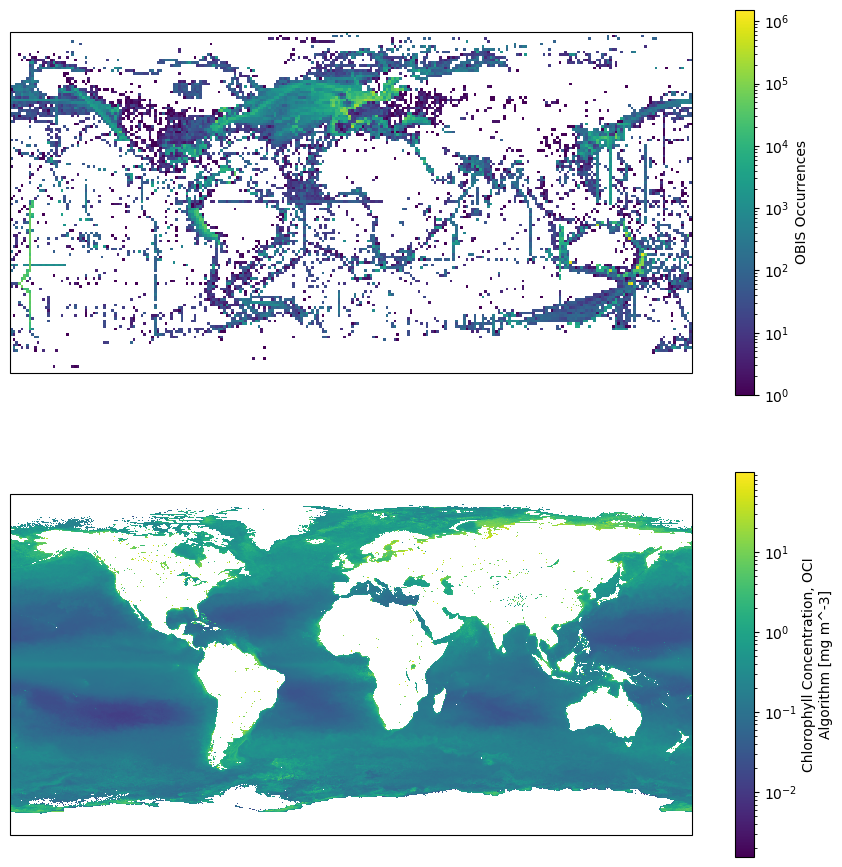

In [8]:
import cartopy.crs as ccrs
import matplotlib.colors as colors
import matplotlib.pyplot as plt

norm = colors.LogNorm()

projection = ccrs.PlateCarree()
fig, (ax0, ax1) = plt.subplots(
    nrows=2,
    subplot_kw={"projection": projection},
    sharex=True,
    sharey=True,
    figsize=(11, 11),
)

ax = gdf.plot(
    column="n",
    norm=colors.LogNorm(),
    legend=True,
    legend_kwds={"label": "OBIS Occurrences"},
    ax=ax0,
)


cs = chlor_a.plot(norm=colors.LogNorm(), ax=ax1)

We can see some features, like a higher density near the coast, currents, and the oligotrophic areas at the gyres centers. As expected, OBIS data density falls off quickly outside of the North Atlantic. However, there is a clear "Gulf Stream signal" in the dataset that is absent in the PACE data. We can envison some sort of interpolation that will use the OBIS data to increase precision and PACE to augument the spatial resolution.

We won't be doing any of that here though. Our goal is to demostrate how to fetch matching data and display them side-by-side. In order to test a better "qualitative" way to compare the data we will average out the PACE data to the OBIS occurrences geometry, and put the data on an hexagonal hierarchical geospatial indexing system (H3) for plotting and comparing each hexagon.

In [9]:
def average_chlor_a(geom):
    xmin, ymin, xmax, ymax = geom

    c = chlor_a.where(
        (xmin <= chlor_a["lon"])
        & (chlor_a["lon"] <= xmax)
        & (ymin <= chlor_a["lat"])
        & (chlor_a["lat"] <= ymax),
        drop=True,
    )
    return float(c.mean().to_numpy())

We will use joblib's `Parallel` to speed up the averages.

In [10]:
import multiprocessing

from joblib import Parallel, delayed

num_cores = multiprocessing.cpu_count()

bounds = gdf["geometry"].bounds.to_numpy()

chlor_avg = Parallel(n_jobs=num_cores)(
    delayed(average_chlor_a)(geom) for geom in bounds
)

gdf["chlor_avg"] = chlor_avg

Now make the H3 index for both datasets.

In [11]:
import h3pandas  # noqa I001

gdf["x"] = gdf["geometry"].centroid.x
gdf["y"] = gdf["geometry"].centroid.y

# The resolution goes from 0-15, using 2 b/c that is the closest to the OBIS squares.
resolution = 2

df = gdf[["x", "y", "n", "chlor_avg"]]

dfh3 = df.h3.geo_to_h3(
    resolution=resolution,
    lat_col="y",
    lng_col="x",
    set_index=True,
)


dfh3 = dfh3.drop(columns=["x", "y"]).groupby(dfh3.index.name).sum()
gdfh3 = dfh3.h3.h3_to_geo_boundary()

We need to correct the longitudes for better plotting at the dateline.

In [12]:
import numpy as np


def fix_geom(geom):
    from shapely import Polygon

    lons, lats = map(list, geom.boundary.coords.xy)
    if max(abs(np.diff(lons))) > 180:
        xx = [x + 360 if x < 0 else x for x in lons]
        return Polygon(zip(xx, lats))
    else:
        return geom


gdfh3["geometry"] = gdfh3["geometry"].apply(fix_geom)
gdfh3["log_n"] = np.log(gdfh3["n"])

Let's take a quick look at the data to see if we are getting the structure we are looking for.

In [13]:
gdfh3

,n,chlor_avg,geometry,log_n
h3_02,,,,
820007fffffffff,667,2.652190,"POLYGON ((36.42872 77.68575, 43.86177 78.00915...",6.502790
82000ffffffffff,1891,4.241199,"POLYGON ((30.78838 80.33975, 40.19373 80.81642...",7.544861
820017fffffffff,119,1.914717,"POLYGON ((48.58085 76.68007, 55.65377 76.66744...",4.779123
82001ffffffffff,1085,4.166355,"POLYGON ((46.68072 79.52276, 55.75077 79.55833...",6.989335
820027fffffffff,2371,6.677391,"POLYGON ((29.20747 75.65094, 35.20921 76.15221...",7.771067
...,...,...,...,...
82f31ffffffffff,9,6.233580,"POLYGON ((-168.19092 -76.36649, -170.0979 -77....",2.197225
82f337fffffffff,71,2.348154,"POLYGON ((180.32561 -73.31022, 177.7638 -74.58...",4.262680
82f367fffffffff,1,0.105472,"POLYGON ((-151.74413 -69.84475, -151.56695 -71...",0.000000


Finally, let's plot the OBIS data at the top and PACE at the lower panel. 

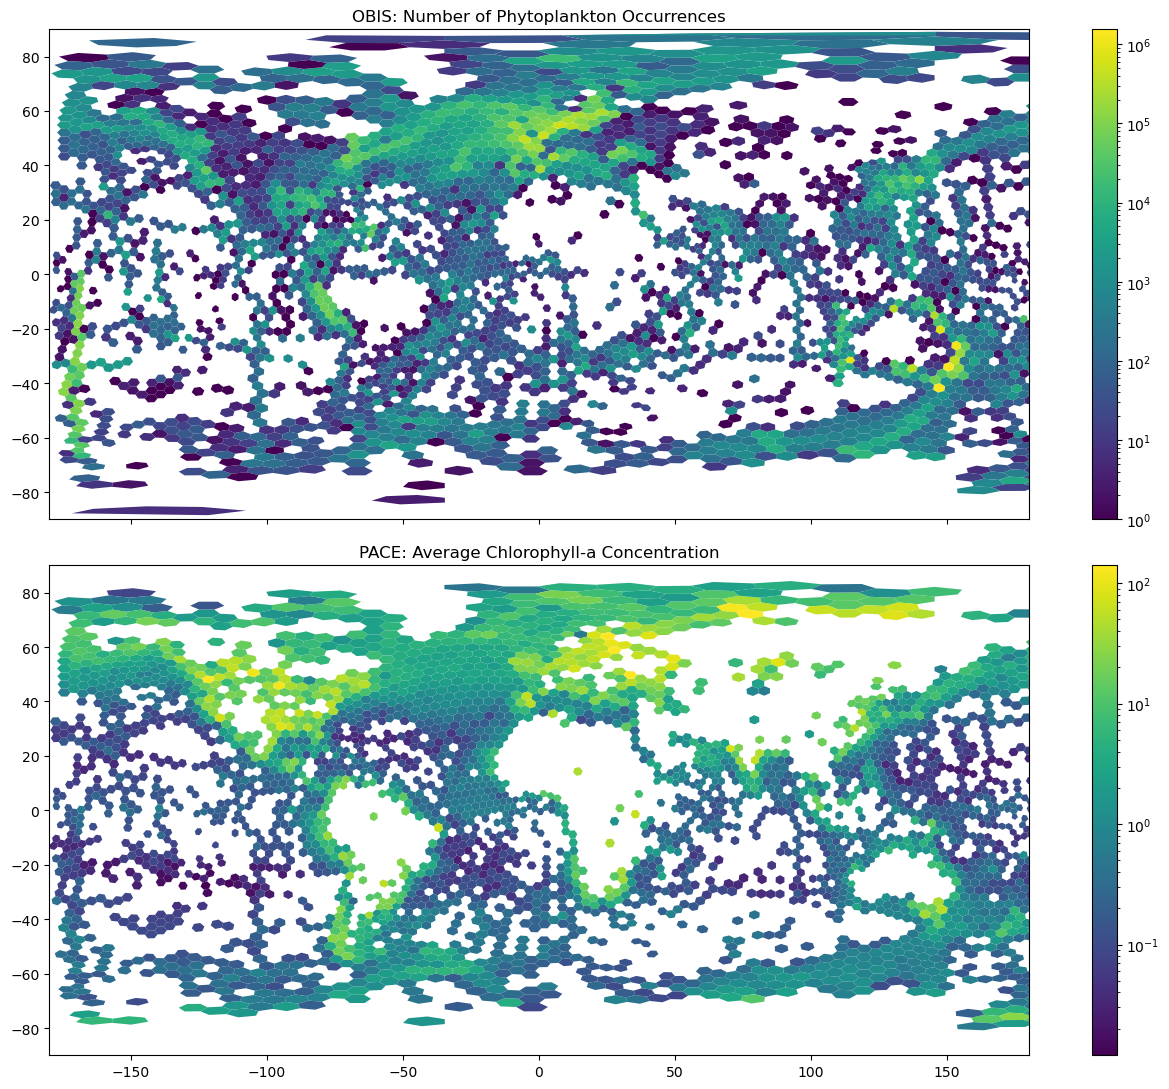

In [14]:
fig, (ax0, ax1) = plt.subplots(nrows=2, figsize=(13, 11), sharex=True, sharey=True)

ax = gdfh3.plot(
    column="n",
    ax=ax0,
    legend=True,
    norm=colors.LogNorm(),
)
gdfh3.plot(
    column="chlor_avg",
    ax=ax1,
    legend=True,
    norm=colors.LogNorm(),
)
ax0.axis([-180, 180, -90, 90])
ax0.set_title("OBIS: Number of Phytoplankton Occurrences")
ax1.set_title("PACE: Average Chlorophyll-a Concentration")
fig.tight_layout()

Done! Hopefully this example will be useful for those using these different data sources.

We would expect to see some rough alignment of higher concentrations of phytoplankton species occurrences (OBIS) with higher concentrations of Chlorophyll-a (PACE). And we do see some of that off Europe and the Gulf Stream. However, we do need to consider that the observing tool for PACE is satellite observations, so that is only presenting surface observations. Whereas OBIS occurrences are the total number of records for one geographic cell, regardless of the depth at which they observed the animal (think of a CTD profile where bottles were collected at the same station but different depths. The OBIS records would be the summation of all the occurrences for that animal at that station, regardless of depth). Additionally, PACE is a snapshot from 2025-01-01 to 2025-12-31 versus OBIS as a cummulative total from 1972-2025.